In [1]:
import zipfile
from pathlib import Path
import xml.etree.ElementTree as ET
import pandas as pd
import os

In [2]:
def zip2dir(input_zip, output_dir):
    # Ensure the directory exists
    os.makedirs(output_dir, exist_ok=True)
    
    # Open the zip file
    with zipfile.ZipFile(input_zip, 'r') as zip_ref:
        # Extract all files
        zip_ref.extractall(output_dir)

In [3]:
relative_path = "./generative-dog-images"

zip2dir(f"{relative_path}/all-dogs.zip", f"{relative_path}/data/")
zip2dir(f"{relative_path}/Annotation.zip", f"{relative_path}/data/")


In [4]:
all_dogs = f"{relative_path}/data/all-dogs/"
annot_dir = f"{relative_path}/data/Annotation/"
all_dogs_files = [Path(all_dogs+i) for i in os.listdir(all_dogs)]
annot_files = [file for file in Path(annot_dir).rglob("*") if file.is_file()]

print(f"all_dogs_files: {all_dogs_files[:5]}")
print(f"annot_files: {annot_files[:5]}")

all_dogs_files: [PosixPath('generative-dog-images/data/all-dogs/n02109961_16718.jpg'), PosixPath('generative-dog-images/data/all-dogs/n02113799_5009.jpg'), PosixPath('generative-dog-images/data/all-dogs/n02091032_6587.jpg'), PosixPath('generative-dog-images/data/all-dogs/n02106166_1429.jpg'), PosixPath('generative-dog-images/data/all-dogs/n02093754_2276.jpg')]
annot_files: [PosixPath('generative-dog-images/data/Annotation/n02097658-silky_terrier/n02097658_98'), PosixPath('generative-dog-images/data/Annotation/n02097658-silky_terrier/n02097658_2535'), PosixPath('generative-dog-images/data/Annotation/n02097658-silky_terrier/n02097658_271'), PosixPath('generative-dog-images/data/Annotation/n02097658-silky_terrier/n02097658_427'), PosixPath('generative-dog-images/data/Annotation/n02097658-silky_terrier/n02097658_4890')]


In [5]:
tmp_map = {i.name: str(i) for i in annot_files}
input_file_dict = {str(i): tmp_map[i.stem] for i in all_dogs_files}

In [6]:
data = []

for k,v in input_file_dict.items():
    # Load and parse the XML file
    tree = ET.parse(v)  # Replace 'file.xml' with the path to your file
    root = tree.getroot()
    
    # Extract metadata
    folder = root.find('folder').text
    filename = root.find('filename').text
    database = root.find('source/database').text
    size = root.find('size')
    width = size.find('width').text
    height = size.find('height').text
    depth = size.find('depth').text
    
    # Extract object details and add metadata for each object
    for obj in root.findall('object'):
        name = obj.find('name').text
        pose = obj.find('pose').text
        truncated = obj.find('truncated').text
        difficult = obj.find('difficult').text
        bndbox = obj.find('bndbox')
        xmin = bndbox.find('xmin').text
        ymin = bndbox.find('ymin').text
        xmax = bndbox.find('xmax').text
        ymax = bndbox.find('ymax').text
    
        # Add a row for each object
        data.append({
            "ImageDirectory": k,
            "AnnotationDirectory": v,
            'Folder': folder,
            'Filename': filename,
            'Database': database,
            'Width': width,
            'Height': height,
            'Depth': depth,
            'ObjectName': name,
            'Pose': pose,
            'Truncated': truncated,
            'Difficult': difficult,
            'XMin': xmin,
            'YMin': ymin,
            'XMax': xmax,
            'YMax': ymax
        })

# Create DataFrame
df = pd.DataFrame(data)

# Display the DataFrame
df.head()

,ImageDirectory,AnnotationDirectory,Folder,Filename,Database,Width,Height,Depth,ObjectName,Pose,Truncated,Difficult,XMin,YMin,XMax,YMax
0,generative-dog-images/data/all-dogs/n02109961_...,generative-dog-images/data/Annotation/n0210996...,02109961,n02109961_16718,ImageNet database,300,420,3,Eskimo_dog,Unspecified,0,0,36,80,200,417
1,generative-dog-images/data/all-dogs/n02113799_...,generative-dog-images/data/Annotation/n0211379...,02113799,n02113799_5009,ImageNet database,302,500,3,standard_poodle,Unspecified,0,0,35,40,248,486
2,generative-dog-images/data/all-dogs/n02091032_...,generative-dog-images/data/Annotation/n0209103...,02091032,n02091032_6587,ImageNet database,358,500,3,Italian_greyhound,Unspecified,0,0,43,35,314,483
3,generative-dog-images/data/all-dogs/n02106166_...,generative-dog-images/data/Annotation/n0210616...,02106166,n02106166_1429,ImageNet database,375,500,3,Border_collie,Unspecified,0,0,40,151,335,461
4,generative-dog-images/data/all-dogs/n02093754_...,generative-dog-images/data/Annotation/n0209375...,02093754,n02093754_2276,ImageNet database,500,375,3,Border_terrier,Unspecified,0,0,37,0,498,374


In [7]:
# General info about the DataFrame
print(df.info())

# Summary statistics of numeric columns
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22125 entries, 0 to 22124
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ImageDirectory       22125 non-null  object
 1   AnnotationDirectory  22125 non-null  object
 2   Folder               22125 non-null  object
 3   Filename             22125 non-null  object
 4   Database             22125 non-null  object
 5   Width                22125 non-null  object
 6   Height               22125 non-null  object
 7   Depth                22125 non-null  object
 8   ObjectName           22125 non-null  object
 9   Pose                 22125 non-null  object
 10  Truncated            22125 non-null  object
 11  Difficult            22125 non-null  object
 12  XMin                 22125 non-null  object
 13  YMin                 22125 non-null  object
 14  XMax                 22125 non-null  object
 15  YMax                 22125 non-null  object
dtypes: o

In [8]:
# Check for missing values
print(df.isnull().sum())

# Find unique values in categorical columns
for col in ['Folder', 'Database', 'ObjectName', 'Pose']:
    print(f"Unique values in {col}: {df[col].unique()}")

ImageDirectory         0
AnnotationDirectory    0
Folder                 0
Filename               0
Database               0
Width                  0
Height                 0
Depth                  0
ObjectName             0
Pose                   0
Truncated              0
Difficult              0
XMin                   0
YMin                   0
XMax                   0
YMax                   0
dtype: int64
Unique values in Folder: ['02109961' '02113799' '02091032' '02106166' '02093754' '02107683'
 '02094114' '02088094' '02097130' '02095314' '02087046' '02110627'
 '02099712' '02088632' '02105251' '02085936' '02093991' '02104029'
 '02096051' '02111500' '02093859' '02112706' '02112137' '02110185'
 '02113186' '02098286' '02089078' '02105162' '02085782' '02107574'
 '02106662' '02097474' '02105641' '02106550' '02095889' '02096294'
 '02102480' '02102040' '02091467' '02101556' '02096585' '02109047'
 '02099849' '02093256' '02092339' '02097209' '02090379' '02112018'
 '02105056' '02086910' '%s

ObjectName
Afghan_hound          287
Maltese_dog           264
Irish_wolfhound       263
Leonberg              256
Scottish_deerhound    246
                     ... 
Rottweiler            153
malinois              153
groenendael           152
Pekinese              152
redbone               151
Name: count, Length: 120, dtype: int64


<Axes: title={'center': 'Object Name Distribution'}, xlabel='ObjectName'>

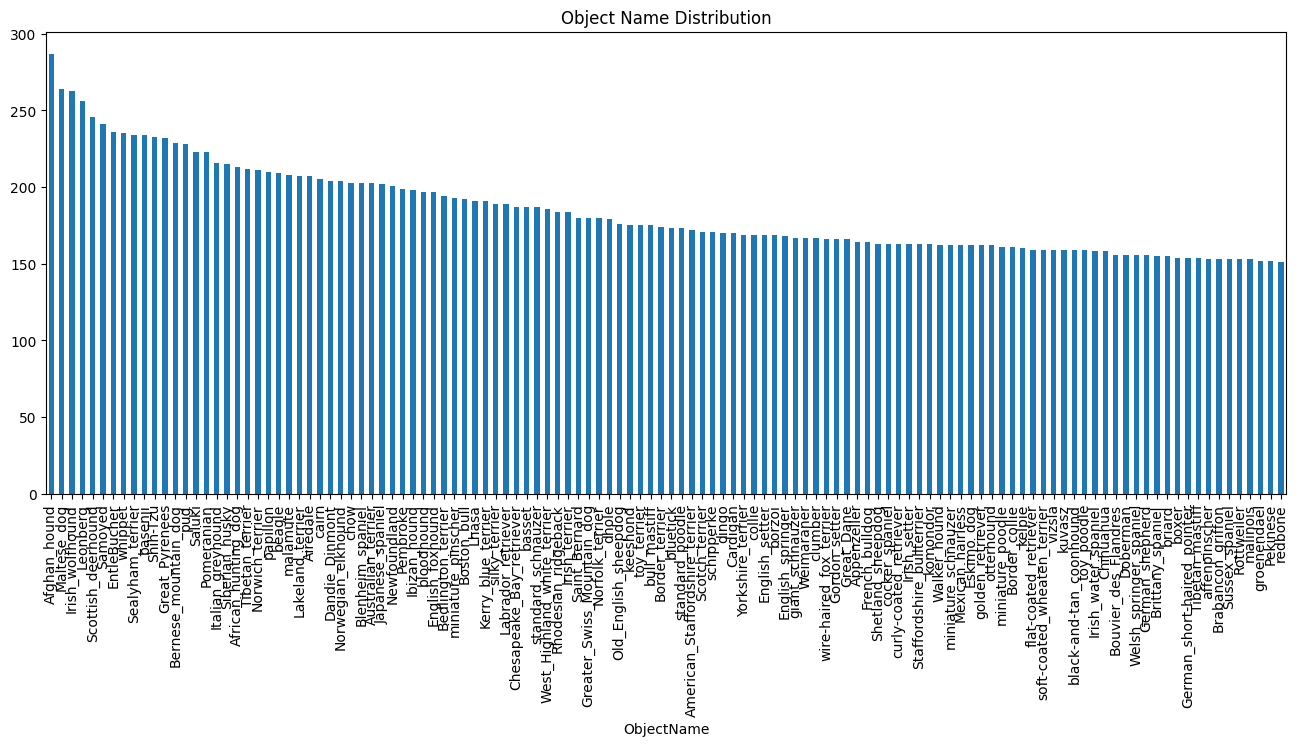

In [9]:
# Count occurrences of each object name
object_counts = df['ObjectName'].value_counts()
print(object_counts)

# Plot the distribution
object_counts.plot(kind='bar', title='Object Name Distribution', figsize=(16, 6))